# Autoencoder implementation

This notebook implements autoencoder using 1 year hourly T_2M data 

In [ ]:
from pathlib import Path
import sys
import importlib
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
for candidate in [repo_root, *repo_root.parents]:
    if (candidate / 'src' / 'my_ml_zoo').exists():
        repo_root = candidate
        break
else:
    raise RuntimeError('Unable to locate repository root containing src/my_ml_zoo')

src_path = repo_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

importlib.invalidate_caches()
for module_name in [
    'my_ml_zoo.data',
    'my_ml_zoo',
    'my_ml_zoo.data.dataset_config',
    'my_ml_zoo.data.file_discovery',
    'my_ml_zoo.data.xarray_dataset',
]:
    if module_name in sys.modules:
        del sys.modules[module_name]

from my_ml_zoo.data import (
    DatasetConfig,
    discover_variable_files,
    select_variable_file,
    open_variable_dataset,
    infer_file_year,
)

### 1. Define dataset 'IAEVALL03'

In [6]:
config_path = repo_root / 'configs' / 'datasets' / 'IAEVALL03.json'
dataset_config = DatasetConfig.load_from_json(config_path)

### 2. Extract the T_2M data for the year 2002

In [7]:
ds_t2m_2000 = open_variable_dataset(dataset_config, 'T_2M', year=2000)['T_2M']
ds_t2m_2000 = ds_t2m_2000.squeeze('height')

n_time, nx, ny = ds_t2m_2000.shape
print(f'( n_time, nx, ny ) = ({n_time}, {nx}, {ny})')

( n_time, nx, ny ) = (8784, 412, 424)


### 3. Divide the data to:
1. training (70%)
2. validation (15%)
3. test (15%)

the split is none consequtively within each month (to get rid of seasonal bias)

In [63]:
rng = np.random.default_rng(42)

months = ds_t2m_2000["time"].dt.month.values

train_idx = []
val_idx = []
test_idx = []

for month in range(1, 13):
    
    idx_month = np.where(months == month)[0]
    
    idx_month = rng.permutation(idx_month)

    n_curr_month = len(idx_month)

    n_train_curr_month = int(0.70 * n_curr_month)
    n_val_curr_month = int(0.15 * n_curr_month)
    n_test_curr_month = n_curr_month - n_train_curr_month - n_val_curr_month

    train_idx.append(idx_month[:n_train_curr_month])
    val_idx.append(idx_month[n_train_curr_month:n_train_curr_month + n_val_curr_month])
    test_idx.append(idx_month[n_train_curr_month + n_val_curr_month:])

train_idx = np.sort(np.concatenate(train_idx))
val_idx = np.sort(np.concatenate(val_idx))
test_idx = np.sort(np.concatenate(test_idx))

train_da = ds_t2m_2000.isel(time=train_idx)
val_da   = ds_t2m_2000.isel(time=val_idx)
test_da  = ds_t2m_2000.isel(time=test_idx)

print('train da shape:',train_da.shape)
print('val da shape:',val_da.shape)
print('test da shape:',test_da.shape)

train da shape: (6139, 412, 424)
val da shape: (1313, 412, 424)
test da shape: (1332, 412, 424)


### 4. Compute the normalization characteristics on the training data

In [64]:
train_mean = train_da.astype(np.float64).mean().item()
train_std = train_da.astype(np.float64).std().item()

print("train_mean =", train_mean)
print("train_std  =", train_std)

train_mean = 285.0142155784381
train_std  = 10.2971076818789


### 5. Normalize the training, validation and test data using the obtained characteristics

In [65]:
train_norm = (train_da - train_mean) / train_std
val_norm   = (val_da   - train_mean) / train_std
test_norm  = (test_da  - train_mean) / train_std

In [66]:
# validation
print("train norm mean:", train_norm.astype(np.float64).mean().item())
print("train norm std :", train_norm.astype(np.float64).std().item())
print("val   norm mean:", val_norm.astype(np.float64).mean().item())
print("val   norm std :", val_norm.astype(np.float64).std().item())

train norm mean: -5.451027059425876e-07
train norm std : 0.9999999985746307
val   norm mean: 0.00295235601495781
val   norm std : 1.0027945030487742


### 6. Save the data as numpy array

In [72]:
X_train = train_norm.values.astype(np.float32)
X_val   = val_norm.values.astype(np.float32)
X_test  = test_norm.values.astype(np.float32)

## 7. Add the channel dimension 

PyTorch convolution layers expect image-like data in the shape [N, C, H, W]

1. N - batch size
2. C - number of channels
3. H - height
4. W - width

In [73]:
print("before channel dim:")
print("X_train:", X_train.shape, X_train.dtype)
print("X_val:", X_val.shape, X_val.dtype)
print("X_test:", X_test.shape, X_test.dtype)

X_train = X_train[:, None, :, :]
X_val   = X_val[:, None, :, :]
X_test  = X_test[:, None, :, :]

print("\nafter channel dim:")
print("X_train:", X_train.shape, X_train.dtype)
print("X_val:", X_val.shape, X_val.dtype)
print("X_test:", X_test.shape, X_test.dtype)

before channel dim:
X_train: (6139, 412, 424) float32
X_val: (1313, 412, 424) float32
X_test: (1332, 412, 424) float32

after channel dim:
X_train: (6139, 1, 412, 424) float32
X_val: (1313, 1, 412, 424) float32
X_test: (1332, 1, 412, 424) float32


## 8. Create simple pytorch dataset

In [75]:
class FullFieldAutoencoderDataset(Dataset):
    def __init__(self, data: np.ndarray):
        if data.ndim != 4:
            raise ValueError(f"Expected shape [N, C, H, W], got {data.shape}")
        self.data = torch.from_numpy(data)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data[idx]
    
train_dataset = FullFieldAutoencoderDataset(X_train)
val_dataset   = FullFieldAutoencoderDataset(X_val)
test_dataset  = FullFieldAutoencoderDataset(X_test)

## 9. Create data loaders

In [ ]:
# the number of samples passed to the model in one forward/backward pass
batch_size = 4

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# num_workers are the number of additional parallell processes to load the data (skip for now)

## 10. Inspect one loaded batch

batch shape: torch.Size([4, 1, 412, 424])
batch dtype: torch.float32
batch min: -3.7408640384674072
batch max: 2.0741748809814453
batch mean: -0.34021130204200745
batch std : 0.7609382271766663


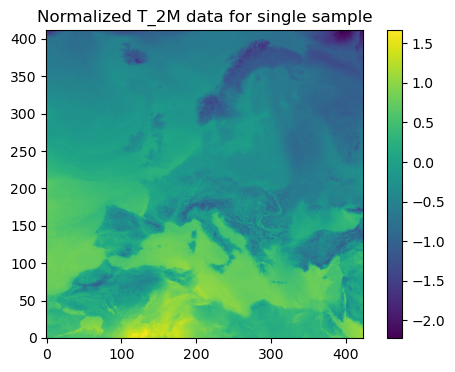

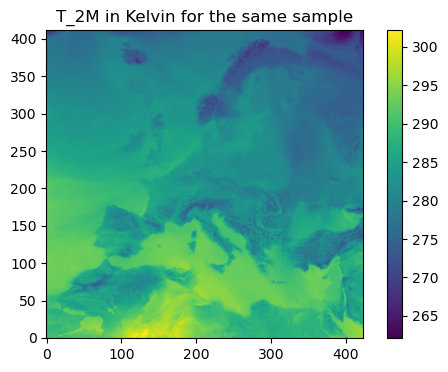

In [99]:
batch = next(iter(train_loader))

# general characteristics
print("batch shape:", batch.shape)
print("batch dtype:", batch.dtype)
print("batch min:", batch.min().item())
print("batch max:", batch.max().item())
print("batch mean:", batch.mean().item())
print("batch std :", batch.std().item())

# 2d plot normalized and in physical space
sample_norm = batch[0, 0].numpy()
sample_phys = sample_norm * train_std + train_mean

plt.figure(figsize=(6, 4))
plt.imshow(sample_norm, origin="lower")
plt.colorbar()
plt.title("Normalized T_2M data for single sample")
plt.show()

plt.figure(figsize=(6, 4))
plt.imshow(sample_phys, origin="lower")
plt.colorbar()
plt.title("T_2M in Kelvin for the same sample")
plt.show()

In [108]:
# save some split info for the future

split_info = {
    "train_idx": train_idx,
    "val_idx": val_idx,
    "test_idx": test_idx,
    "train_mean": train_mean,
    "train_std": train_std,
}

## 11. Create first tiny autoencoder architecture 

with matching input and output shape

In [116]:
import torch.nn as nn


# Input:                  1 × 412 × 424
# Conv + ReLU + Pool      8 × 206 × 212
# Conv + ReLU + Pool     16 × 103 × 106
# Conv + ReLU + Pool     32 ×  51 ×  53
# Deconv + ReLU          16 × 103 × 106
# Deconv + ReLU           8 × 206 × 212
# Deconv                  1 × 412 × 424

class SimpleAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                32, 16,
                kernel_size=2,
                stride=2,
                output_padding=(1, 0)
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 8, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(8, 1, kernel_size=2, stride=2),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

## 12. Test forward propagation

In [117]:
x = next(iter(train_loader))
model = SimpleAutoencoder()
y = model(x)

In [118]:
print(x.shape)
print(y.shape)

torch.Size([4, 1, 412, 424])
torch.Size([4, 1, 412, 424])
